,Sample ID,Sludge %,Plasticizer %,Density,σm Flexural (MPa),mean σc Compression (MPa)
0,C1,0.0,0.0,0.002070,15.058,73.351
1,C2,0.0,0.0,0.002122,13.920,77.499
2,C3,0.0,0.0,0.002108,15.412,79.204
3,1,1.0,0.0,0.002097,11.896,70.210
4,2,1.0,0.0,0.002116,13.340,69.879



Final fitted kernel for σ_m:
0.944**2 * Matern(length_scale=[0.205, 0.00161, 1e+03], nu=1.5) + WhiteKernel(noise_level=0.0803)

Final fitted kernel for σ_c:
2.09**2 * Matern(length_scale=[20.6, 1e+03, 4.65], nu=1.5) + WhiteKernel(noise_level=0.0798)


  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

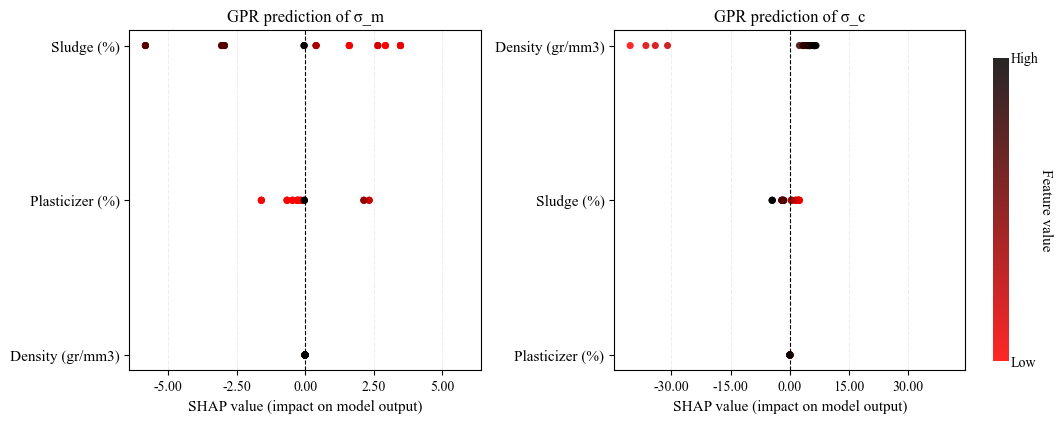

Saved files:
1. GPR_SHAP_outputs.xlsx
2. Figure_4_GPR_SHAP_summary.pdf
3. Figure_4_GPR_SHAP_summary.jpeg


In [ ]:
# =========================================================
# GPR-SHAP Summary Plot
# Corrected version for journal-style figure
# Excel columns:
# Sample ID | Sludge % | Plasticizer % | Density |
# σm Flexural (MPa) | mean σc Compression (MPa)
# =========================================================

# If needed in Colab:
# !pip install shap openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
import shap
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    Matern,
    ConstantKernel as C,
    WhiteKernel
)

warnings.filterwarnings("ignore")

# =========================================================
# 0) Figure style
# =========================================================
try:
    font_path = "/content/TimesNewRoman.ttf"
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    mpl.rcParams["font.family"] = font_name
except Exception:
    mpl.rcParams["font.family"] = "Times New Roman"

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

# red -> black colormap
red_to_black = LinearSegmentedColormap.from_list(
    "RedBlack", ["#FF0000", "#000000"]
)

# =========================================================
# 1) Load Excel file
# =========================================================
data = pd.read_excel("Final.xlsx")
data.columns = data.columns.astype(str).str.strip()

required_cols = [
    "Sample ID",
    "Sludge %",
    "Plasticizer %",
    "Density",
    "σm Flexural (MPa)",
    "mean σc Compression (MPa)"
]

missing_cols = [c for c in required_cols if c not in data.columns]
if len(missing_cols) > 0:
    raise ValueError(f"Missing columns in Excel file: {missing_cols}")

data = data[required_cols].dropna().reset_index(drop=True)

X_cols = ["Sludge %", "Plasticizer %", "Density"]
y_sigma_m_col = "σm Flexural (MPa)"
y_sigma_c_col = "mean σc Compression (MPa)"

X = data[X_cols].copy()
y_sigma_m = data[y_sigma_m_col].values
y_sigma_c = data[y_sigma_c_col].values

# names shown in figure
X_display = X.copy()
X_display.columns = [
    "Sludge (%)",
    "Plasticizer (%)",
    "Density (gr/mm3)"
]

display(data.head())

# =========================================================
# 2) Build final GPR model
# =========================================================
def selected_gpr_kernel():
    return (
        C(1.0, (1e-3, 1e3))
        * Matern(
            length_scale=np.ones(len(X_cols)),
            length_scale_bounds=(1e-3, 1e3),
            nu=1.5
        )
        + WhiteKernel(
            noise_level=1e-3,
            noise_level_bounds=(1e-8, 1e1)
        )
    )

def build_gpr_model():
    base_gpr = GaussianProcessRegressor(
        kernel=selected_gpr_kernel(),
        normalize_y=False,
        n_restarts_optimizer=10,
        random_state=42
    )

    pipe = Pipeline([
        ("x_scaler", StandardScaler()),
        ("gpr", base_gpr)
    ])

    model = TransformedTargetRegressor(
        regressor=pipe,
        transformer=StandardScaler()
    )

    return model

gpr_sigma_m = build_gpr_model()
gpr_sigma_c = build_gpr_model()

gpr_sigma_m.fit(X, y_sigma_m)
gpr_sigma_c.fit(X, y_sigma_c)

print("\nFinal fitted kernel for σ_m:")
print(gpr_sigma_m.regressor_.named_steps["gpr"].kernel_)

print("\nFinal fitted kernel for σ_c:")
print(gpr_sigma_c.regressor_.named_steps["gpr"].kernel_)

# =========================================================
# 3) Prediction functions for SHAP
# =========================================================
def predict_sigma_m(arr):
    arr_df = pd.DataFrame(arr, columns=X_cols)
    return gpr_sigma_m.predict(arr_df)

def predict_sigma_c(arr):
    arr_df = pd.DataFrame(arr, columns=X_cols)
    return gpr_sigma_c.predict(arr_df)

# =========================================================
# 4) Kernel SHAP
# =========================================================
X_values = X.values
background = X_values

explainer_sigma_m = shap.KernelExplainer(predict_sigma_m, background)
shap_values_sigma_m = explainer_sigma_m.shap_values(X_values)

explainer_sigma_c = shap.KernelExplainer(predict_sigma_c, background)
shap_values_sigma_c = explainer_sigma_c.shap_values(X_values)

if isinstance(shap_values_sigma_m, list):
    shap_values_sigma_m = shap_values_sigma_m[0]

if isinstance(shap_values_sigma_c, list):
    shap_values_sigma_c = shap_values_sigma_c[0]

# =========================================================
# 5) Save SHAP values
# =========================================================
shap_sigma_m_df = pd.DataFrame(shap_values_sigma_m, columns=X_display.columns)
shap_sigma_c_df = pd.DataFrame(shap_values_sigma_c, columns=X_display.columns)

importance_sigma_m = pd.DataFrame({
    "Feature": X_display.columns,
    "Mean |SHAP| for σ_m": np.abs(shap_values_sigma_m).mean(axis=0)
}).sort_values("Mean |SHAP| for σ_m", ascending=False)

importance_sigma_c = pd.DataFrame({
    "Feature": X_display.columns,
    "Mean |SHAP| for σ_c": np.abs(shap_values_sigma_c).mean(axis=0)
}).sort_values("Mean |SHAP| for σ_c", ascending=False)

with pd.ExcelWriter("GPR_SHAP_outputs.xlsx", engine="openpyxl") as writer:
    data_out = data.copy()
    data_out = data_out.rename(columns={
        "Density": "Density (gr/mm3)",
        "σm Flexural (MPa)": "σ_m (MPa)",
        "mean σc Compression (MPa)": "σ_c (MPa)"
    })

    data_out.to_excel(writer, sheet_name="Data", index=False)
    shap_sigma_m_df.to_excel(writer, sheet_name="SHAP_sigma_m", index=False)
    shap_sigma_c_df.to_excel(writer, sheet_name="SHAP_sigma_c", index=False)
    importance_sigma_m.to_excel(writer, sheet_name="Importance_sigma_m", index=False)
    importance_sigma_c.to_excel(writer, sheet_name="Importance_sigma_c", index=False)

# =========================================================
# 6) Custom SHAP summary plot
# =========================================================
def shap_summary_template(ax, shap_values, X_df, title_text):
    mean_abs = np.abs(shap_values).mean(axis=0)
    order = np.argsort(mean_abs)[::-1]

    shap_sort = shap_values[:, order]
    vals_sort = X_df.values[:, order]
    feat_sort = [X_df.columns[i] for i in order]

    rng = np.random.default_rng(42)

    for i in range(len(feat_sort)):
        feature_vals = vals_sort[:, i]
        shap_vals = shap_sort[:, i]

        vmin, vmax = np.nanmin(feature_vals), np.nanmax(feature_vals)
        if vmax > vmin:
            norm_vals = (feature_vals - vmin) / (vmax - vmin)
        else:
            norm_vals = np.full_like(feature_vals, 0.05, dtype=float)

        y_jitter = rng.normal(loc=i, scale=0, size=len(shap_vals))

        sc = ax.scatter(
            shap_vals,
            y_jitter,
            c=norm_vals,
            cmap=red_to_black,
            s=26,
            edgecolors="none",
            alpha=0.85
        )

    ax.set_yticks(np.arange(len(feat_sort)))
    ax.set_yticklabels(feat_sort, fontsize=11)
    ax.invert_yaxis()

    ax.set_xlabel("SHAP value (impact on model output)", fontsize=11)
    ax.set_title(title_text, fontsize=12, pad=6)

    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=11)

    xmax = np.nanmax(np.abs(shap_sort))
    ax.set_xlim(-xmax * 1.10, xmax * 1.10)

    ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
    ax.grid(axis="x", linestyle="--", alpha=0.22)

    ax.xaxis.set_major_locator(mticker.MaxNLocator(6))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    return sc

# =========================================================
# 7) Combined figure
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6))
plt.subplots_adjust(left=0.10, right=0.86, bottom=0.16, top=0.90, wspace=0.38)

sc1 = shap_summary_template(
    axes[0],
    shap_values_sigma_m,
    X_display,
    "GPR prediction of σ_m"
)

sc2 = shap_summary_template(
    axes[1],
    shap_values_sigma_c,
    X_display,
    "GPR prediction of σ_c"
)

# =========================================================
# 8) Colorbar outside the figure
# =========================================================
cax = fig.add_axes([0.885, 0.18, 0.015, 0.66])
cbar = fig.colorbar(sc2, cax=cax)

cbar.set_ticks([0, 1.0])
cbar.set_ticklabels(["Low", "High"])
cbar.outline.set_visible(False)

for side in ["left", "right", "top", "bottom"]:
    cbar.ax.spines[side].set_visible(False)

cbar.ax.tick_params(axis="y", length=0, labelsize=10)
for t in cbar.ax.get_yticklabels():
    t.set_ha("left")
    t.set_x(0.8)

cbar.set_label("Feature value", fontsize=11, rotation=270, labelpad=10)

# =========================================================
# 9) Save figure
# =========================================================
plt.savefig("Figure_4_GPR_SHAP_summary.pdf", bbox_inches="tight")
plt.savefig("Figure_4_GPR_SHAP_summary.jpeg", format="jpeg", dpi=300, bbox_inches="tight")
plt.show()

print("Saved files:")
print("1. GPR_SHAP_outputs.xlsx")
print("2. Figure_4_GPR_SHAP_summary.pdf")
print("3. Figure_4_GPR_SHAP_summary.jpeg")